# SPam Email EDA Dataset

## Exploratory Data Analysis for Spam Message Classification

This notebook performs accurate EDA on the provided `spam.csv` dataset.

### Dataset columns
- `v1` → target label (`ham` / `spam`)
- `v2` → message text
- `Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4` → mostly empty auxiliary columns

The analysis is designed specifically for an NLP spam-classification project rather than copying numerical analyses from an unrelated placement dataset.


In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
from collections import Counter

pd.set_option("display.max_colwidth", 120)


In [2]:
# 2. Load spam.csv
from pathlib import Path

possible_paths = [
    Path("/content/spam.csv"),
    Path("/mnt/data/spam.csv"),
    Path("spam.csv")
]

csv_path = next((p for p in possible_paths if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError("spam.csv was not found. Upload spam.csv before running this notebook.")

df_raw = pd.read_csv(csv_path, encoding="latin-1")
print("Loaded:", csv_path)
print("Original dataset shape:", df_raw.shape)
df_raw.head()


Loaded: /mnt/data/spam.csv
Original dataset shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives around here though",NaN,NaN,NaN


## 1. Dataset Overview

The first stage checks dataset dimensions, columns, data types and sample records.


In [3]:
# 3. Basic dataset information
print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nData types:")
print(df_raw.dtypes)

print("\nFirst 5 rows:")
display(df_raw.head())

print("\nLast 5 rows:")
display(df_raw.tail())


Shape: (5572, 5)

Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data types:
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives around here though",NaN,NaN,NaN



Last 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,"This is the 2nd time we have tried 2 contact u. U have won the å£750 Pound prize. 2 claim is easy, call 087187272008...",NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other suggestions?",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


## 2. Missing Values and Data Quality

In [4]:
# 4. Missing-value summary
missing_summary = pd.DataFrame({
    "Missing Values": df_raw.isnull().sum(),
    "Missing Percentage": (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
missing_summary


,Missing Values,Missing Percentage
v1,0,0.00
v2,0,0.00
Unnamed: 2,5522,99.10
Unnamed: 3,5560,99.78
Unnamed: 4,5566,99.89


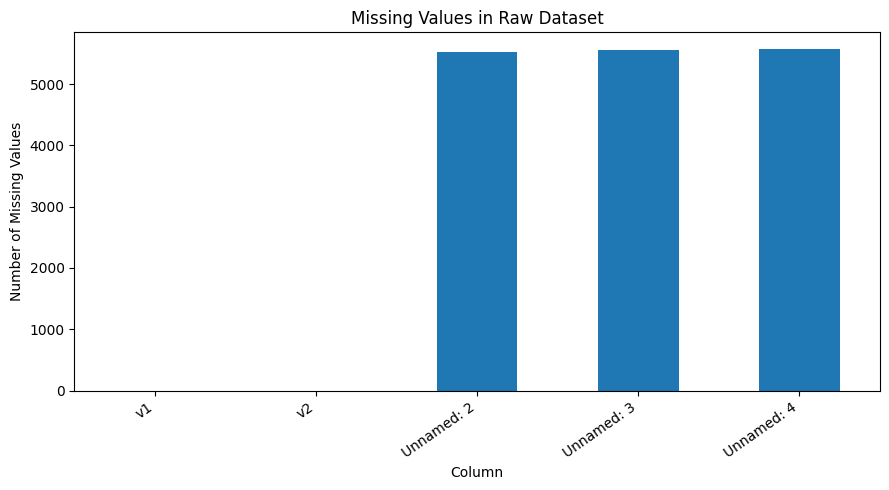

In [5]:
# 5. Missing-value visualization
missing_counts = df_raw.isnull().sum()

plt.figure(figsize=(9, 5))
missing_counts.plot(kind="bar")
plt.title("Missing Values in Raw Dataset")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### Observation

The important columns `v1` and `v2` contain no missing values. The three unnamed columns contain mostly missing values and are not meaningful inputs for spam classification.


In [6]:
# 6. Duplicate analysis
duplicate_count = df_raw.duplicated().sum()

print("Total duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_count / len(df_raw) * 100, 2), "%")
display(df_raw[df_raw.duplicated()].head(10))


Total duplicate rows: 403
Duplicate percentage: 7.23 %


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
102,ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Calle...,NaN,NaN,NaN
153,ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Calle...,NaN,NaN,NaN
206,ham,"As I entered my cabin my PA said, '' Happy B'day Boss !!''. I felt special. She askd me 4 lunch. After lunch she inv...",NaN,NaN,NaN
222,ham,"Sorry, I'll call later",NaN,NaN,NaN
325,ham,No calls..messages..missed calls,NaN,NaN,NaN
338,ham,"Sorry, I'll call later",NaN,NaN,NaN
356,spam,Congratulations ur awarded 500 of CD vouchers or 125gift guaranteed & Free entry 2 100 wkly draw txt MUSIC to 87066 ...,NaN,NaN,NaN
443,ham,"Sorry, I'll call later",NaN,NaN,NaN
532,ham,Gudnite....tc...practice going on,NaN,NaN,NaN
654,ham,Did u got that persons story,NaN,NaN,NaN


## 3. Data Cleaning

For the project:
1. Keep only `v1` and `v2`.
2. Rename them to `label` and `message`.
3. Remove duplicate label-message pairs.


In [7]:
# 7. Clean the dataset
df = df_raw[["v1", "v2"]].copy()
df.columns = ["label", "message"]

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal :", after)
print("Duplicates removed          :", before - after)
print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nUnique labels:", df["label"].unique())

df.head()


Rows before duplicate removal: 5572
Rows after duplicate removal : 5169
Duplicates removed          : 403

Missing values after cleaning:
label      0
message    0
dtype: int64

Unique labels: ['ham' 'spam']


,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


## 4. Ham vs Spam Class Distribution

Class distribution is important because an imbalanced target can make accuracy alone misleading.


,Count,Percentage
label,,
ham,4516,87.37
spam,653,12.63


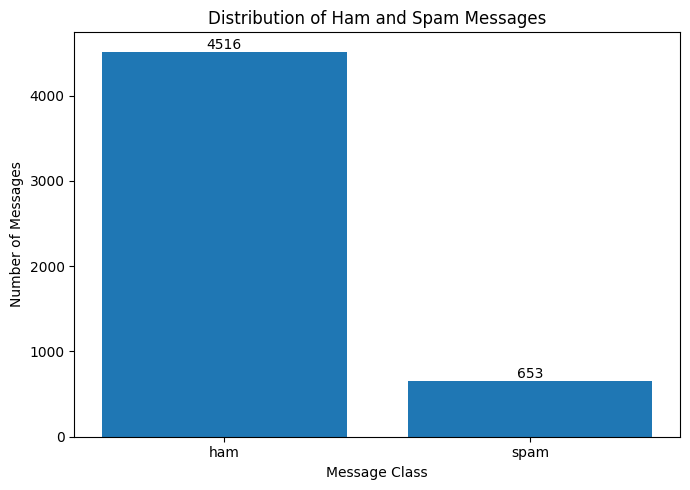

In [8]:
# 8. Class distribution
class_counts = df["label"].value_counts().reindex(["ham", "spam"])
class_percentages = (class_counts / len(df) * 100).round(2)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})
display(class_distribution)

plt.figure(figsize=(7, 5))
bars = plt.bar(class_counts.index, class_counts.values)
plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Class")
plt.ylabel("Number of Messages")

for bar, value in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, str(value),
             ha="center", va="bottom")

plt.tight_layout()
plt.show()


### Observation

The dataset contains considerably more ham messages than spam messages. This indicates **class imbalance**, so precision, recall and F1-score should later be considered alongside accuracy.


## 5. Text Feature Engineering for EDA

Because the original dataset contains text rather than numerical predictor columns, meaningful numerical features are derived from each message.


In [9]:
# 9. Engineer text-based numerical features
df["char_count"] = df["message"].astype(str).apply(len)
df["word_count"] = df["message"].astype(str).apply(lambda x: len(x.split()))
df["digit_count"] = df["message"].astype(str).apply(lambda x: sum(ch.isdigit() for ch in x))
df["uppercase_count"] = df["message"].astype(str).apply(lambda x: sum(ch.isupper() for ch in x))
df["punctuation_count"] = df["message"].astype(str).apply(
    lambda x: sum(ch in string.punctuation for ch in x)
)

df.head()


,label,message,char_count,word_count,digit_count,uppercase_count,punctuation_count
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,20,0,3,9
1,ham,Ok lar... Joking wif u oni...,29,6,0,2,6
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...,155,28,25,10,6
3,ham,U dun say so early hor... U c already then say...,49,11,0,2,6
4,ham,"Nah I don't think he goes to usf, he lives around here though",61,13,0,2,2


In [10]:
# 10. Descriptive statistics
numeric_features = [
    "char_count",
    "word_count",
    "digit_count",
    "uppercase_count",
    "punctuation_count"
]

print("Overall descriptive statistics:")
display(df[numeric_features].describe().round(2))

print("\nMean values by class:")
display(df.groupby("label")[numeric_features].mean().round(2))


Overall descriptive statistics:


,char_count,word_count,digit_count,uppercase_count,punctuation_count
count,5169.00,5169.00,5169.00,5169.00,5169.00
mean,78.98,15.34,2.21,5.34,4.09
std,58.24,11.07,6.03,11.16,4.44
min,2.00,1.00,0.00,0.00,0.00
25%,36.00,7.00,0.00,1.00,2.00
50%,60.00,12.00,0.00,2.00,3.00
75%,117.00,22.00,1.00,4.00,6.00
max,910.00,171.00,47.00,128.00,133.00



Mean values by class:


,char_count,word_count,digit_count,uppercase_count,punctuation_count
label,,,,,
ham,70.46,14.13,0.29,3.90,3.87
spam,137.89,23.68,15.45,15.25,5.65


## 6. Message Length Analysis

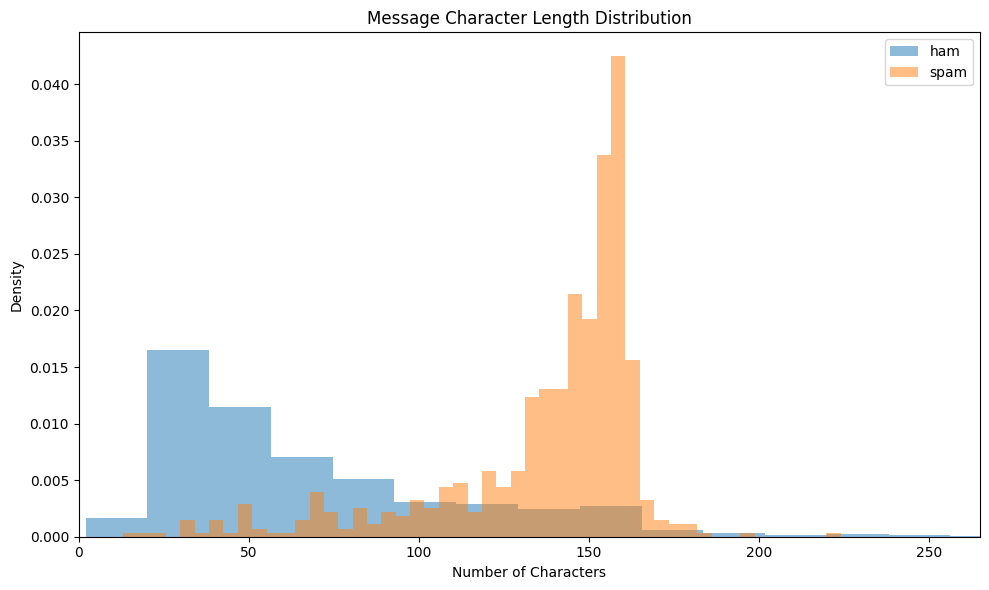

In [11]:
# 11. Character-count distribution for ham and spam
plt.figure(figsize=(10, 6))

for label in ["ham", "spam"]:
    values = df.loc[df["label"] == label, "char_count"]
    plt.hist(values, bins=50, alpha=0.5, density=True, label=label)

plt.title("Message Character Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Density")
plt.xlim(0, df["char_count"].quantile(0.99))
plt.legend()
plt.tight_layout()
plt.show()


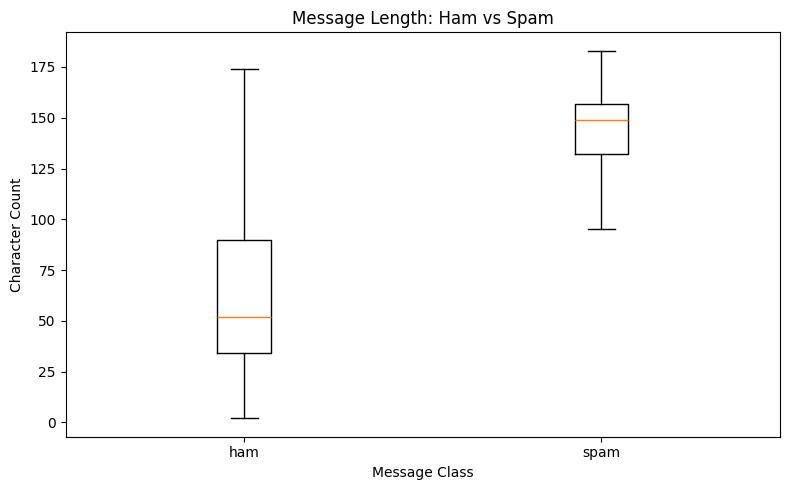

In [12]:
# 12. Character-count boxplot
ham_chars = df.loc[df["label"] == "ham", "char_count"]
spam_chars = df.loc[df["label"] == "spam", "char_count"]

plt.figure(figsize=(8, 5))
plt.boxplot([ham_chars, spam_chars], tick_labels=["ham", "spam"], showfliers=False)
plt.title("Message Length: Ham vs Spam")
plt.xlabel("Message Class")
plt.ylabel("Character Count")
plt.tight_layout()
plt.show()


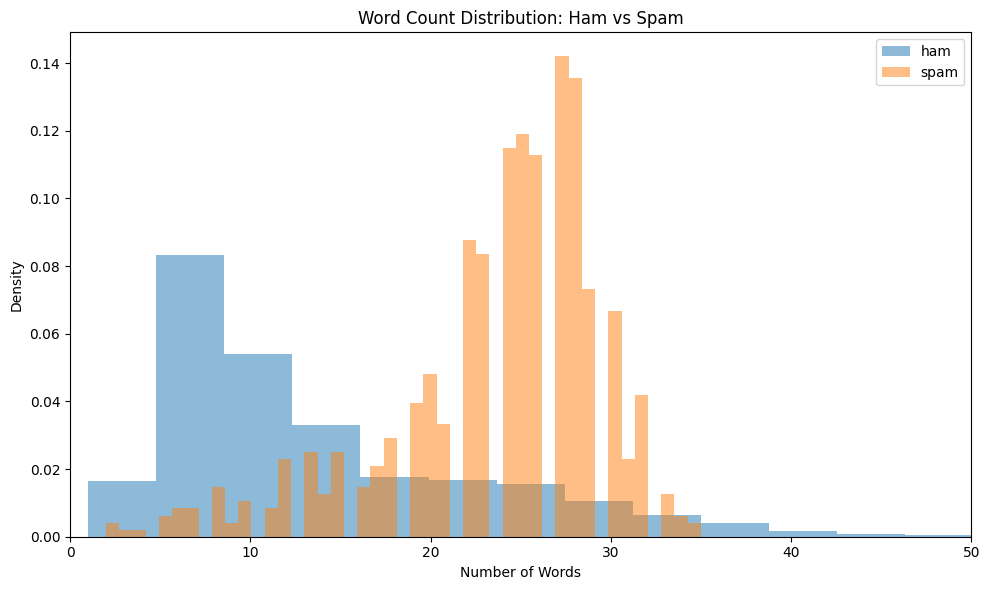

In [13]:
# 13. Word-count distribution for ham and spam
plt.figure(figsize=(10, 6))

for label in ["ham", "spam"]:
    values = df.loc[df["label"] == label, "word_count"]
    plt.hist(values, bins=45, alpha=0.5, density=True, label=label)

plt.title("Word Count Distribution: Ham vs Spam")
plt.xlabel("Number of Words")
plt.ylabel("Density")
plt.xlim(0, df["word_count"].quantile(0.99))
plt.legend()
plt.tight_layout()
plt.show()


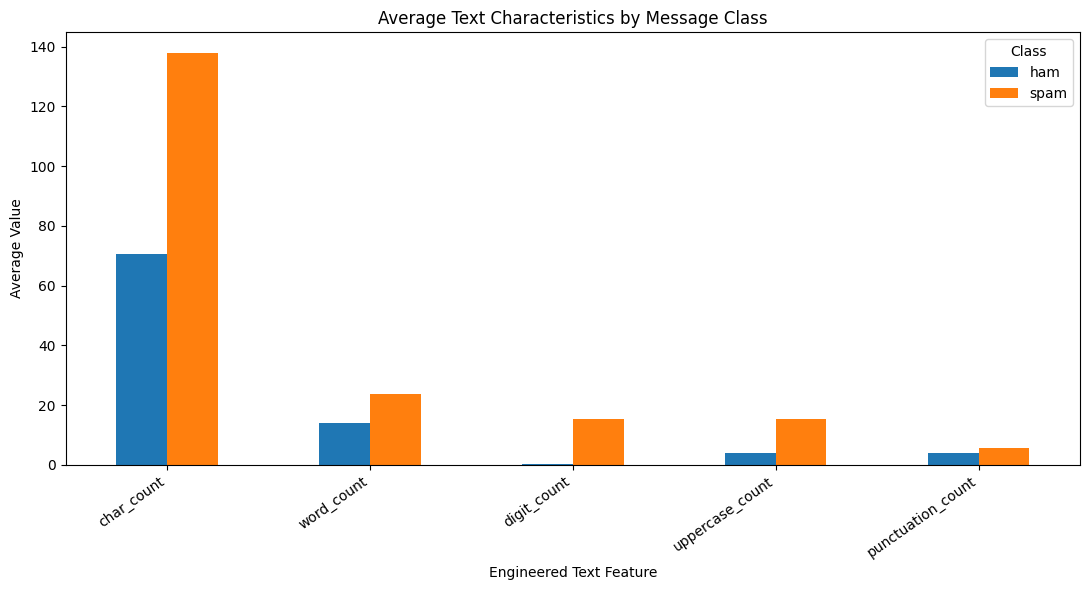

In [14]:
# 14. Mean engineered features by class
feature_means = df.groupby("label")[numeric_features].mean().T
feature_means = feature_means[["ham", "spam"]]

feature_means.plot(kind="bar", figsize=(11, 6))
plt.title("Average Text Characteristics by Message Class")
plt.xlabel("Engineered Text Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Class")
plt.tight_layout()
plt.show()


## 7. Correlation Analysis

The original spam dataset has no meaningful numerical predictors. Therefore, correlation is calculated only for the engineered text features.


,char_count,word_count,digit_count,uppercase_count,punctuation_count
char_count,1.00,0.97,0.38,0.36,0.62
word_count,0.97,1.00,0.29,0.32,0.57
digit_count,0.38,0.29,1.00,0.34,0.16
uppercase_count,0.36,0.32,0.34,1.00,0.23
punctuation_count,0.62,0.57,0.16,0.23,1.00


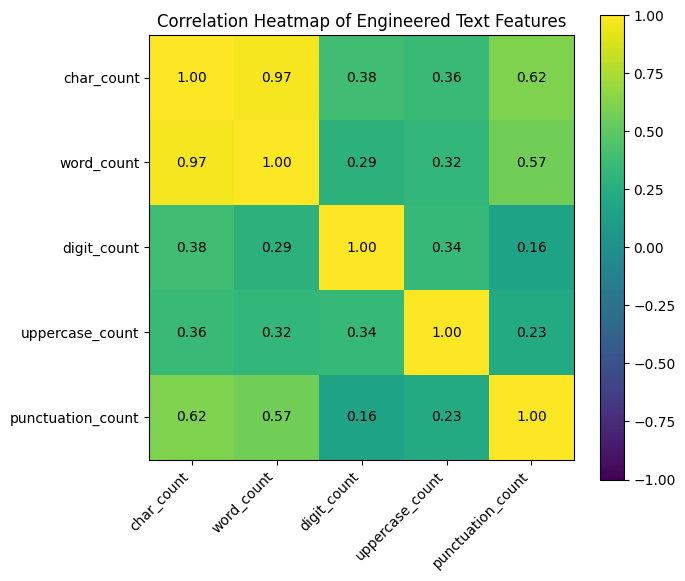

In [15]:
# 15. Correlation matrix
corr = df[numeric_features].corr()
display(corr.round(2))

plt.figure(figsize=(7, 6))
image = plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(image)
plt.xticks(range(len(numeric_features)), numeric_features, rotation=45, ha="right")
plt.yticks(range(len(numeric_features)), numeric_features)

for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Heatmap of Engineered Text Features")
plt.tight_layout()
plt.show()


### Observation

The correlation matrix describes relationships among derived text statistics such as character count and word count. It does not directly show which individual words make a message spam.


## 8. Frequent Word Analysis

This section examines frequently occurring words separately in ham and spam messages. The frequency analysis is descriptive and does not replace the preprocessing used later for model training.


In [16]:
# 16. Tokenization for descriptive word-frequency analysis
stop_words = {
    "a","an","the","and","or","but","if","then","than","to","of","in","on","at","for","from",
    "with","by","is","it","this","that","these","those","i","you","he","she","we","they","me",
    "my","your","our","their","be","been","being","am","are","was","were","do","does","did",
    "have","has","had","as","so","not","no","can","could","would","should","will","just","up",
    "out","about","what","when","where","who","how","all","any","some","there","here"
}

def tokenize(text):
    cleaned = "".join(ch.lower() if ch.isalpha() else " " for ch in str(text))
    return [word for word in cleaned.split()
            if len(word) > 1 and word not in stop_words]

def top_words(series, n=15):
    counter = Counter()
    for message in series:
        counter.update(tokenize(message))
    return pd.DataFrame(counter.most_common(n), columns=["word", "count"])

top_ham = top_words(df.loc[df["label"] == "ham", "message"], 15)
top_spam = top_words(df.loc[df["label"] == "spam", "message"], 15)

print("Top words in HAM messages:")
display(top_ham)

print("Top words in SPAM messages:")
display(top_spam)


Top words in HAM messages:


,word,count
0,get,301
1,gt,288
2,lt,287
3,now,282
4,ok,255
5,go,245
6,ll,232
7,got,227
8,know,225
9,like,222


Top words in SPAM messages:


,word,count
0,call,322
1,free,197
2,now,168
3,txt,141
4,ur,119
5,stop,114
6,mobile,111
7,text,109
8,claim,96
9,reply,96


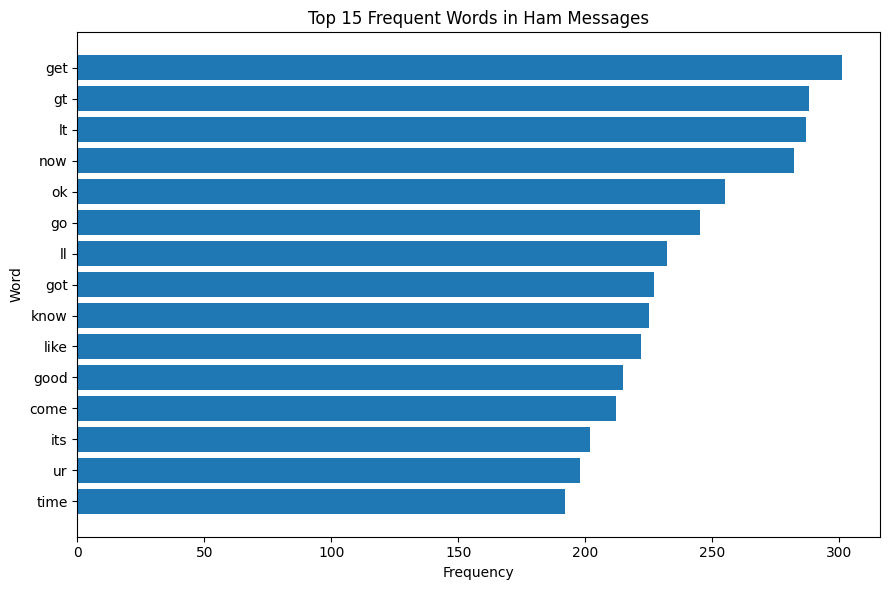

In [17]:
# 17. Top words in ham
plt.figure(figsize=(9, 6))
plt.barh(top_ham["word"][::-1], top_ham["count"][::-1])
plt.title("Top 15 Frequent Words in Ham Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


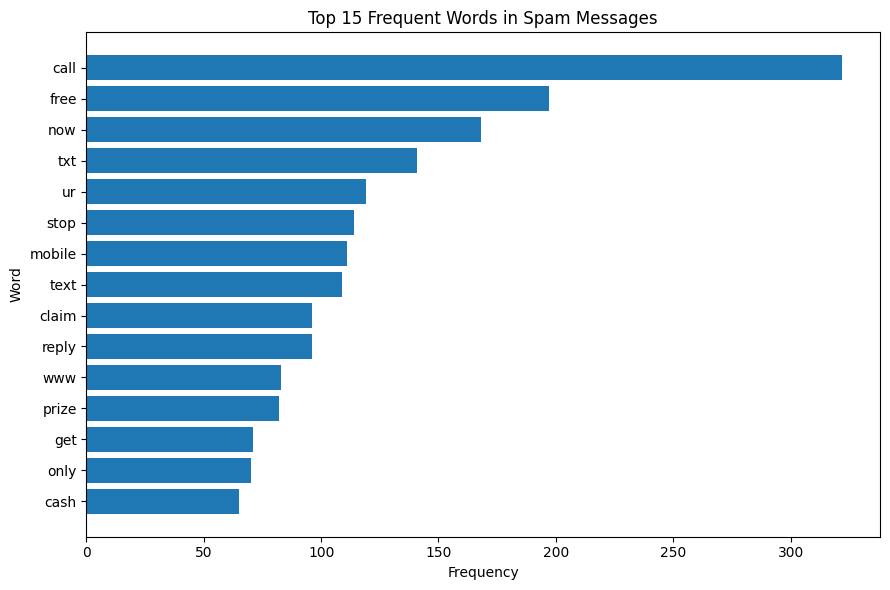

In [18]:
# 18. Top words in spam
plt.figure(figsize=(9, 6))
plt.barh(top_spam["word"][::-1], top_spam["count"][::-1])
plt.title("Top 15 Frequent Words in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


## 9. Final EDA Summary

The EDA establishes that:

- The raw dataset contains 5 columns, but only the label and message columns are relevant.
- The unnamed columns are mostly empty and are removed.
- Duplicate rows are identified and removed.
- The target classes are imbalanced.
- Text-specific numerical features are created for meaningful statistical analysis.
- Message length, word count, digits, uppercase characters and punctuation can be compared between ham and spam.
- Correlation is applied only to engineered numerical text features.
- Frequent-word analysis provides interpretable vocabulary patterns for ham and spam.

### Recommended 3–4 PPT EDA pages
1. **Dataset Overview & Data Cleaning**
2. **Ham vs Spam Class Distribution**
3. **Message Length & Text Feature Analysis**
4. **Correlation + Frequent Words / Key EDA Findings**
